# Advanced Topics in Machine Learning - Assignment 0
## Task 4: Training Variational Autoencoders
### 1. Setup and Data Loading

In [1]:
import os

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

os.environ["TQDM_NOTEBOOK"] = "0"
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

Using device: cuda


### 2. Model Architecture

In [2]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        # Encoder
        self.enc_conv1 = nn.Conv2d(1, 32, 4, stride=2, padding=1)  # 28x28 -> 14x14
        self.enc_conv2 = nn.Conv2d(32, 64, 4, stride=2, padding=1) # 14x14 -> 7x7
        self.enc_fc = nn.Linear(64*7*7, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.dec_fc = nn.Linear(latent_dim, 256)
        self.dec_fc2 = nn.Linear(256, 64*7*7)
        self.dec_deconv1 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1) # 7x7 -> 14x14
        self.dec_deconv2 = nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1)  # 14x14 -> 28x28

    def encode(self, x):
        x = F.relu(self.enc_conv1(x))
        x = F.relu(self.enc_conv2(x))
        x = x.view(x.size(0), -1)
        h = F.relu(self.enc_fc(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h = F.relu(self.dec_fc(z))
        h = F.relu(self.dec_fc2(h))
        h = h.view(-1, 64, 7, 7)
        h = F.relu(self.dec_deconv1(h))
        x_recon = torch.sigmoid(self.dec_deconv2(h))
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### 3. Loss Function
The VAE loss function is composed of two parts:
1.  **Reconstruction Loss**: Mean Squared Error (MSE) loss for reconstruction.
2.  **KL Divergence**: This term acts as a regularizer, pushing the learned latent distribution `q(z|x)` to be close to the prior `p(z)` (a standard normal distribution).


In [3]:
def loss_function(recon_x, x, mu, logvar, beta=0.5):
    MSE = F.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + beta * KLD

### 4. Training and Validating the VAE

In [4]:
def train(epoch, model, train_loader, optimizer, beta=0.5):
    model.train()
    train_loss = 0
    loop = tqdm(train_loader, leave=True)
    for batch_idx, (data, _) in enumerate(loop):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, log_var = model(data)
        loss = loss_function(recon_batch, data, mu, log_var, beta)
        
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
        loop.set_description(f"Epoch [{epoch} out of {epochs}]")
        loop.set_postfix(loss=loss.item(), beta=beta)
        
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')


def validate(epoch, model, test_loader, beta=0.5):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            recon_batch, mu, log_var = model(data)
            test_loss += loss_function(recon_batch, data, mu, log_var, beta).item()

    test_loss /= len(test_loader.dataset)
    print(f"====> Test set loss: {test_loss:.4f}")
    return test_loss


epochs = 25
beta = 0.5
train_losses = []
val_losses = []
for epoch in range(1, epochs + 1):
    train(epoch, model, train_loader, optimizer, beta)
    val_loss = validate(epoch, model, test_loader, beta)
    val_losses.append(val_loss)

Epoch [1 out of 25]: 100%|██████████| 469/469 [00:03<00:00, 128.97it/s, beta=0.5, loss=2.42e+3]


====> Epoch: 1 Average loss: 33.9376
====> Test set loss: 23.8636


Epoch [2 out of 25]: 100%|██████████| 469/469 [00:03<00:00, 141.54it/s, beta=0.5, loss=2e+3]   


====> Epoch: 2 Average loss: 22.4855
====> Test set loss: 21.4840


Epoch [3 out of 25]: 100%|██████████| 469/469 [00:03<00:00, 140.58it/s, beta=0.5, loss=1.95e+3]


...

====> Epoch: 23 Average loss: 17.8619
====> Test set loss: 18.2107


Epoch [24 out of 25]: 100%|██████████| 469/469 [00:03<00:00, 139.81it/s, beta=0.5, loss=1.74e+3]


====> Epoch: 24 Average loss: 17.8155
====> Test set loss: 18.0999


Epoch [25 out of 25]: 100%|██████████| 469/469 [00:03<00:00, 139.85it/s, beta=0.5, loss=1.68e+3]


====> Epoch: 25 Average loss: 17.8132
====> Test set loss: 18.0652


### 5. Visualize Reconstructions and Generations

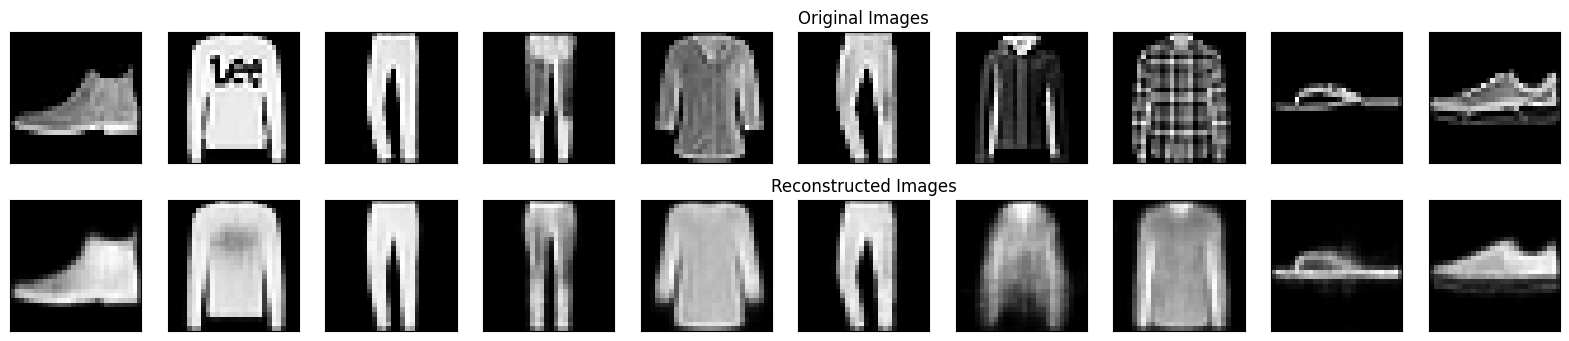

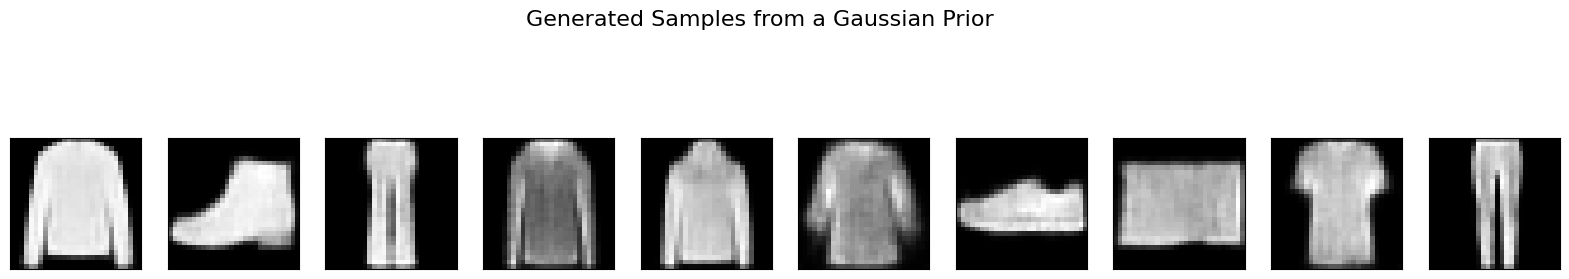

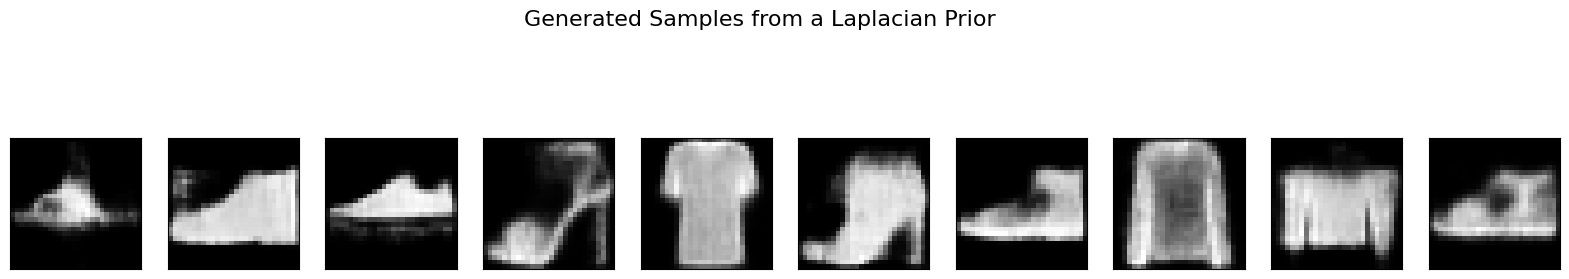

In [5]:
def visualize_reconstructions(model, data_loader):
    model.eval()
    with torch.no_grad():
        data, _ = next(iter(data_loader))
        data = data.to(device)
        recon, _, _ = model(data)
        
        n = 10
        plt.figure(figsize=(20, 4))
        for i in range(n):
            # Display original
            ax = plt.subplot(2, n, i + 1)
            plt.imshow(data[i].cpu().squeeze(), cmap='gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
            if i == n//2:
                ax.set_title("Original Images")

            # Display reconstruction
            ax = plt.subplot(2, n, i + 1 + n)
            plt.imshow(recon[i].cpu().squeeze(), cmap='gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
            if i == n//2:
                ax.set_title("Reconstructed Images")
        plt.show()

visualize_reconstructions(model, test_loader)

def visualize_generations(model, num_samples=10, prior='gaussian', latent_dim=20):
    model.eval()
    with torch.no_grad():
        if prior == 'gaussian':
            z = torch.randn(num_samples, latent_dim).to(device)
        elif prior == 'laplacian':
            laplace_dist = torch.distributions.laplace.Laplace(0, 1)
            z = laplace_dist.sample((num_samples, latent_dim)).to(device)
        else:
            raise ValueError('Invalid prior specified')
            
        samples = model.decode(z).cpu()
        
        plt.figure(figsize=(20, 4))
        for i in range(num_samples):
            ax = plt.subplot(1, num_samples, i + 1)
            plt.imshow(samples[i].squeeze(), cmap='gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
        plt.suptitle(f'Generated Samples from a {prior.capitalize()} Prior', fontsize=16)
        plt.show()

visualize_generations(model, num_samples=10, prior='gaussian')
visualize_generations(model, num_samples=10, prior='laplacian')

### 6. Posterior Collapse Investigation

Training with HIGH KL weight to force posterior collapse:
====> Epoch: 1 Recon Loss: 70.3195, KL Loss: 0.0020
====> Epoch: 2 Recon Loss: 68.4174, KL Loss: 0.0011
====> Epoch: 3 Recon Loss: 68.3813, KL Loss: 0.0008
====> Epoch: 4 Recon Loss: 68.3480, KL Loss: 0.0006
====> Epoch: 5 Recon Loss: 68.3399, KL Loss: 0.0005

Training with NORMAL KL weight:
====> Epoch: 1 Recon Loss: 31.8088, KL Loss: 8.6447
====> Epoch: 2 Recon Loss: 18.1838, KL Loss: 10.0230
====> Epoch: 3 Recon Loss: 16.2965, KL Loss: 10.3197
====> Epoch: 4 Recon Loss: 15.3342, KL Loss: 10.4811
====> Epoch: 5 Recon Loss: 14.7787, KL Loss: 10.6290


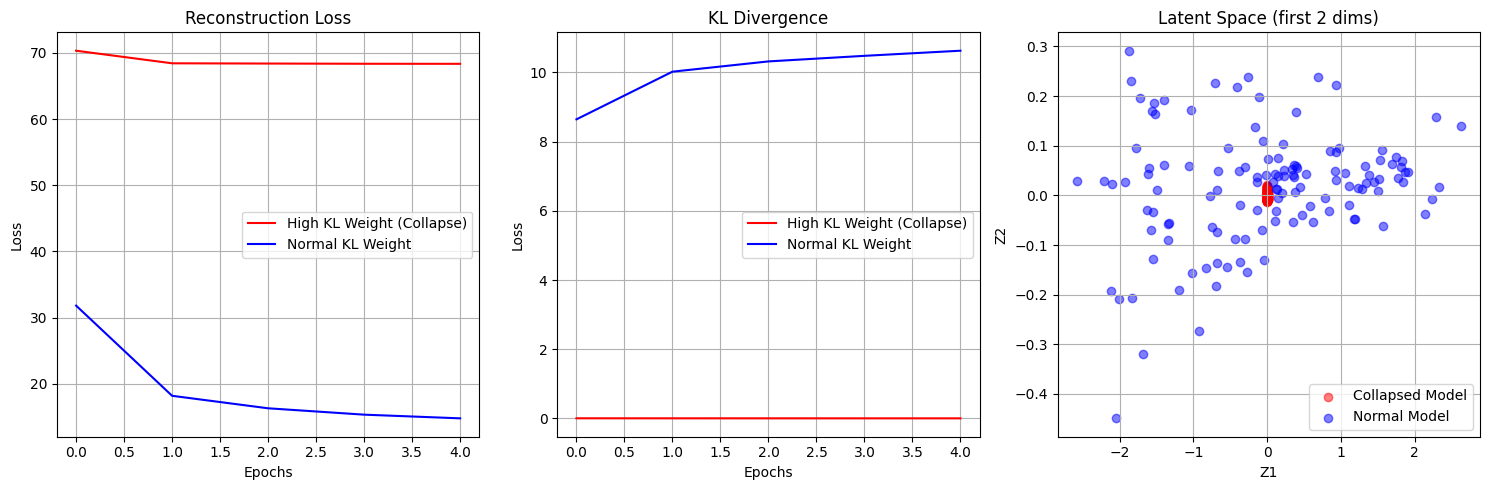

In [6]:
def train_and_track_loss(epoch, model, train_loader, optimizer, beta=0.5):
    model.train()
    total_recon_loss = 0
    total_kl_loss = 0
    for _, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, log_var = model(data)
        
        reconstruction_loss = F.mse_loss(recon_batch, data, reduction='sum')
        kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        
        loss = reconstruction_loss + beta * kl_divergence
        loss.backward()
        optimizer.step()
        
        total_recon_loss += reconstruction_loss.item()
        total_kl_loss += kl_divergence.item()
        
    avg_recon_loss = total_recon_loss / len(train_loader.dataset)
    avg_kl_loss = total_kl_loss / len(train_loader.dataset)
    
    print(f'====> Epoch: {epoch} Recon Loss: {avg_recon_loss:.4f}, KL Loss: {avg_kl_loss:.4f}')
    return avg_recon_loss, avg_kl_loss

def train_with_high_kl(epoch, model, train_loader, optimizer, kl_weight=10.0):
    model.train()
    total_recon_loss = 0
    total_kl_loss = 0
    for _, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, log_var = model(data)
        
        reconstruction_loss = F.mse_loss(recon_batch, data, reduction='sum')
        kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        
        # Force posterior collapse with high KL weight
        loss = reconstruction_loss + kl_weight * kl_divergence
        loss.backward()
        optimizer.step()
        
        total_recon_loss += reconstruction_loss.item()
        total_kl_loss += kl_divergence.item()
        
    avg_recon_loss = total_recon_loss / len(train_loader.dataset)
    avg_kl_loss = total_kl_loss / len(train_loader.dataset)
    
    print(f'====> Epoch: {epoch} Recon Loss: {avg_recon_loss:.4f}, KL Loss: {avg_kl_loss:.4f}')
    return avg_recon_loss, avg_kl_loss

# Train model with forced posterior collapse
model_collapse = VAE().to(device)
optimizer_collapse = optim.Adam(model_collapse.parameters(), lr=1e-3)

print("Training with HIGH KL weight to force posterior collapse:")
recon_losses_collapse = []
kl_losses_collapse = []
for epoch in range(1, 6):  # Fewer epochs to see collapse quickly
    recon_loss, kl_loss = train_with_high_kl(epoch, model_collapse, train_loader, optimizer_collapse, kl_weight=50.0)
    recon_losses_collapse.append(recon_loss)
    kl_losses_collapse.append(kl_loss)

# Train normal model for comparison  
model_normal = VAE().to(device)
optimizer_normal = optim.Adam(model_normal.parameters(), lr=1e-3)

print("\nTraining with NORMAL KL weight:")
recon_losses_normal = []
kl_losses_normal = []
for epoch in range(1, 6):
    recon_loss, kl_loss = train_and_track_loss(epoch, model_normal, train_loader, optimizer_normal, beta=0.5)
    recon_losses_normal.append(recon_loss)
    kl_losses_normal.append(kl_loss)

# Plot comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(recon_losses_collapse, label='High KL Weight (Collapse)', color='red')
plt.plot(recon_losses_normal, label='Normal KL Weight', color='blue')
plt.title('Reconstruction Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(kl_losses_collapse, label='High KL Weight (Collapse)', color='red')
plt.plot(kl_losses_normal, label='Normal KL Weight', color='blue')
plt.title('KL Divergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Check latent space variance
plt.subplot(1, 3, 3)
model_collapse.eval()
model_normal.eval()
with torch.no_grad():
    test_data, _ = next(iter(test_loader))
    test_data = test_data.to(device)
    
    mu_collapse, _ = model_collapse.encode(test_data)
    mu_normal, _ = model_normal.encode(test_data)
    
    plt.scatter(mu_collapse[:, 0].cpu(), mu_collapse[:, 1].cpu(), alpha=0.5, label='Collapsed Model', color='red')
    plt.scatter(mu_normal[:, 0].cpu(), mu_normal[:, 1].cpu(), alpha=0.5, label='Normal Model', color='blue')
    plt.title('Latent Space (first 2 dims)')
    plt.xlabel('Z1')
    plt.ylabel('Z2')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

### 7. Mitigating Posterior Collapse
To mitigate posterior collapse, we will implement **KL annealing**. This involves adding a weight to the KL divergence term that gradually increases from 0 to 0.5 over a set number of epochs. This gives the model a chance to learn meaningful reconstructions before the regularizer becomes too strong.

In [7]:
def train_with_annealing(epoch, model, train_loader, optimizer, anneal_end_epoch, final_beta):
    model.train()
    loop = tqdm(train_loader, leave=True)
    for _, (data, _) in enumerate(loop):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, log_var = model(data)
        
        reconstruction_loss = F.mse_loss(recon_batch, data, reduction='sum')
        kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())        
        kl_weight = min(final_beta, (epoch / anneal_end_epoch) * final_beta)
        
        loss = reconstruction_loss + kl_weight * kl_divergence
        loss.backward()
        optimizer.step()
        
        loop.set_description(f"Epoch [{epoch} out of {epochs}]")
        loop.set_postfix(loss=loss.item(), kl_weight=kl_weight)

model_mitigated = VAE().to(device)
optimizer_mitigated = optim.Adam(model_mitigated.parameters(), lr=1e-3)

anneal_epochs = 10
for epoch in range(1, epochs + 1):
    train_with_annealing(epoch, model_mitigated, train_loader, optimizer_mitigated, anneal_epochs, final_beta=0.5)

Epoch [25 out of 25]: 100%|██████████| 469/469 [00:03<00:00, 128.75it/s, kl_weight=0.5, loss=1.78e+3]


### 8. Comparison of Results

Collapsed Model Generations (High KL Weight):


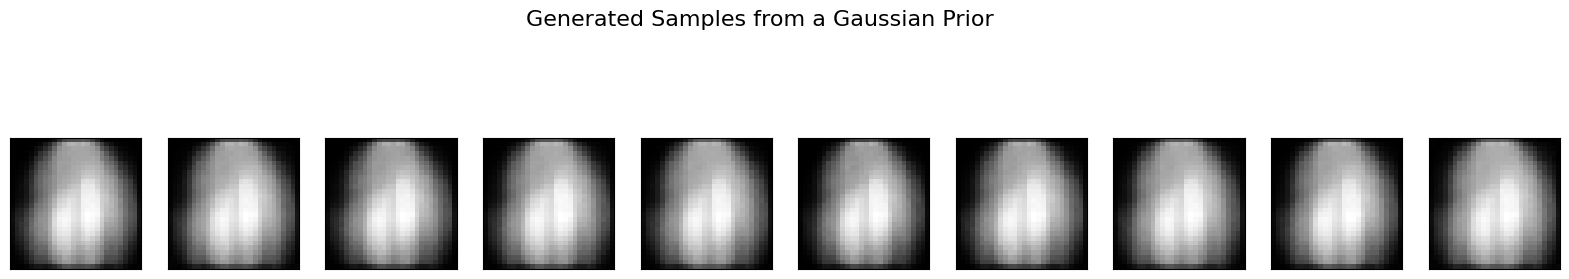


Normal Model Generations:


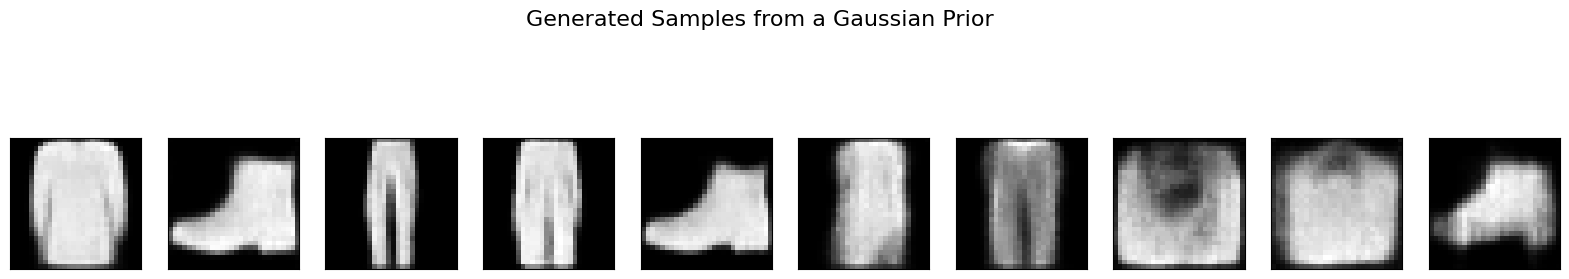


Mitigated Model Generations (KL Annealing):


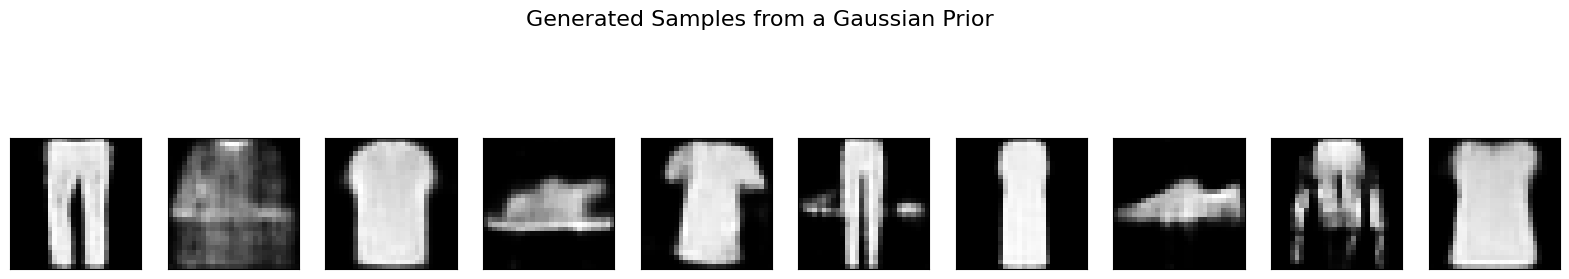

In [8]:
print('Collapsed Model Generations (High KL Weight):')
visualize_generations(model_collapse)

print('\nNormal Model Generations:')
visualize_generations(model_normal)

print('\nMitigated Model Generations (KL Annealing):')
visualize_generations(model_mitigated)